#  **Heart Disease Risk Prediction Using Machine Learning**



### **Motivation**
Heart disease is the leading cause of death worldwide. Early detection can save lives by allowing timely intervention. Machine Learning can help predict the risk of heart disease using patient data such as age, blood pressure, cholesterol, and lifestyle factors.

This project demonstrates how classical machine learning techniques can be used to estimate heart disease risk from routine clinical parameters.

####  **Dataset Description**
*   Source: UCI Heart Disease Dataset
*   Total Features: 13
    (Clinical and demographic attributes such as age, sex, cholesterol levels, resting blood pressure, and ECG results.)
*   Target Variable: target
    *   1 → Heart Disease Present
    *   0 → No Heart Disease
    
####  **Methodology Overview**
This project follows a standard supervised machine learning pipeline:
1.   Data loading and preprocessing of clinical features
2.   Train–test split to assess model generalization
3.   Feature scaling for magnitude-sensitive models
4.   Training and comparison of multiple classification algorithms
5.   Model evaluation using performance metrics and interpretability

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [2]:
#Data Description
df = pd.read_csv("../data/heart.csv")

print(f"Dataset shape: {df.shape}")
print("="*50)

df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
print("Data Types and Non-Null Counts:")
print("=" * 50)
df.info()

print("\nStatistical Summary:")
print("=" * 50)
df.describe()

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


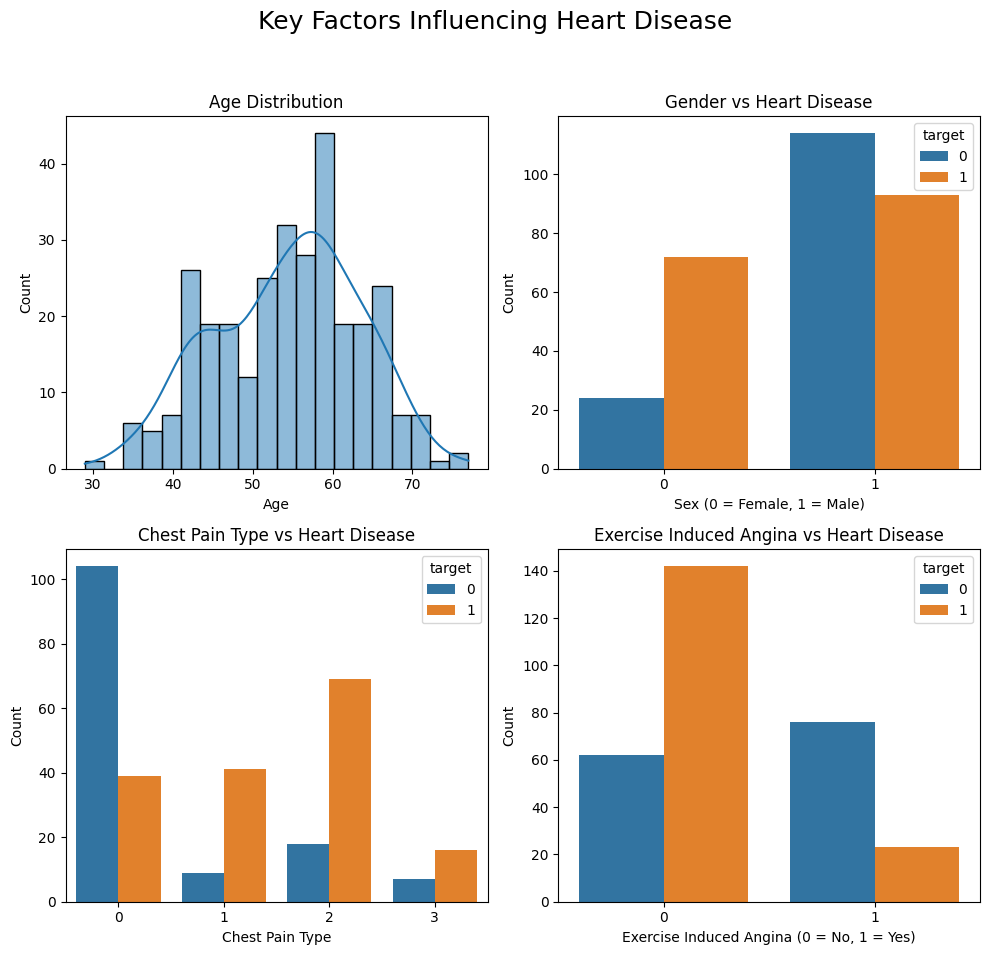

In [5]:
# Data Visulaization
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Age Distribution
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

# Gender vs Heart Disease
sns.countplot(x='sex', hue='target', data=df, ax=axes[0, 1])
axes[0, 1].set_title("Gender vs Heart Disease")
axes[0, 1].set_xlabel("Sex (0 = Female, 1 = Male)")
axes[0, 1].set_ylabel("Count")

# Chest Pain Type vs Heart Disease
sns.countplot(x='cp', hue='target', data=df, ax=axes[1, 0])
axes[1, 0].set_title("Chest Pain Type vs Heart Disease")
axes[1, 0].set_xlabel("Chest Pain Type")
axes[1, 0].set_ylabel("Count")

# Exercise Induced Angina vs Heart Disease
sns.countplot(x='exang', hue='target', data=df, ax=axes[1, 1])
axes[1, 1].set_title("Exercise Induced Angina vs Heart Disease")
axes[1, 1].set_xlabel("Exercise Induced Angina (0 = No, 1 = Yes)")
axes[1, 1].set_ylabel("Count")

plt.suptitle("Key Factors Influencing Heart Disease", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

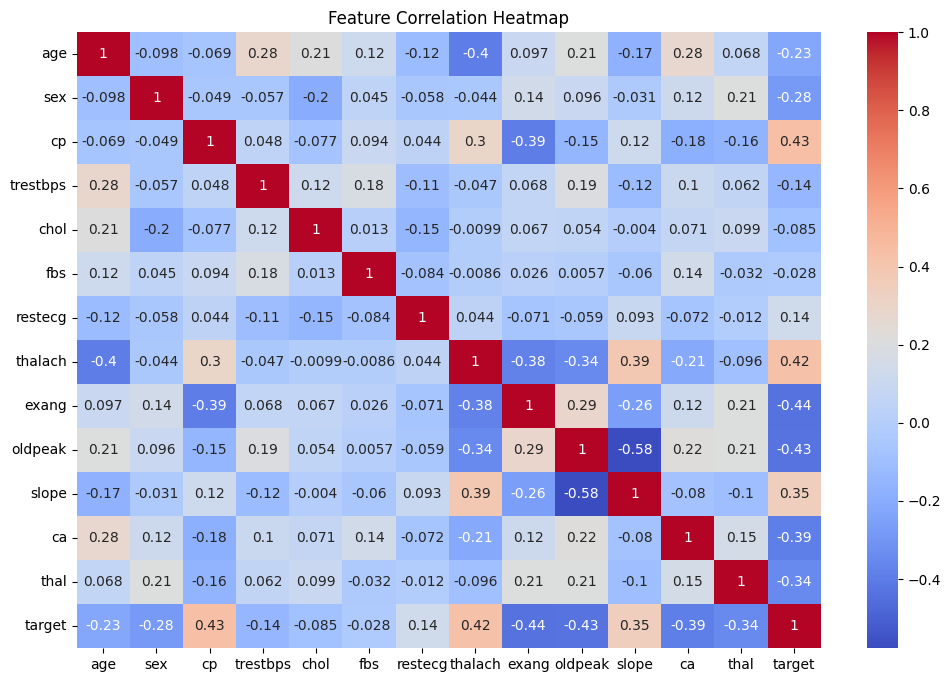

In [6]:
#Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

<Figure size 1200x800 with 0 Axes>

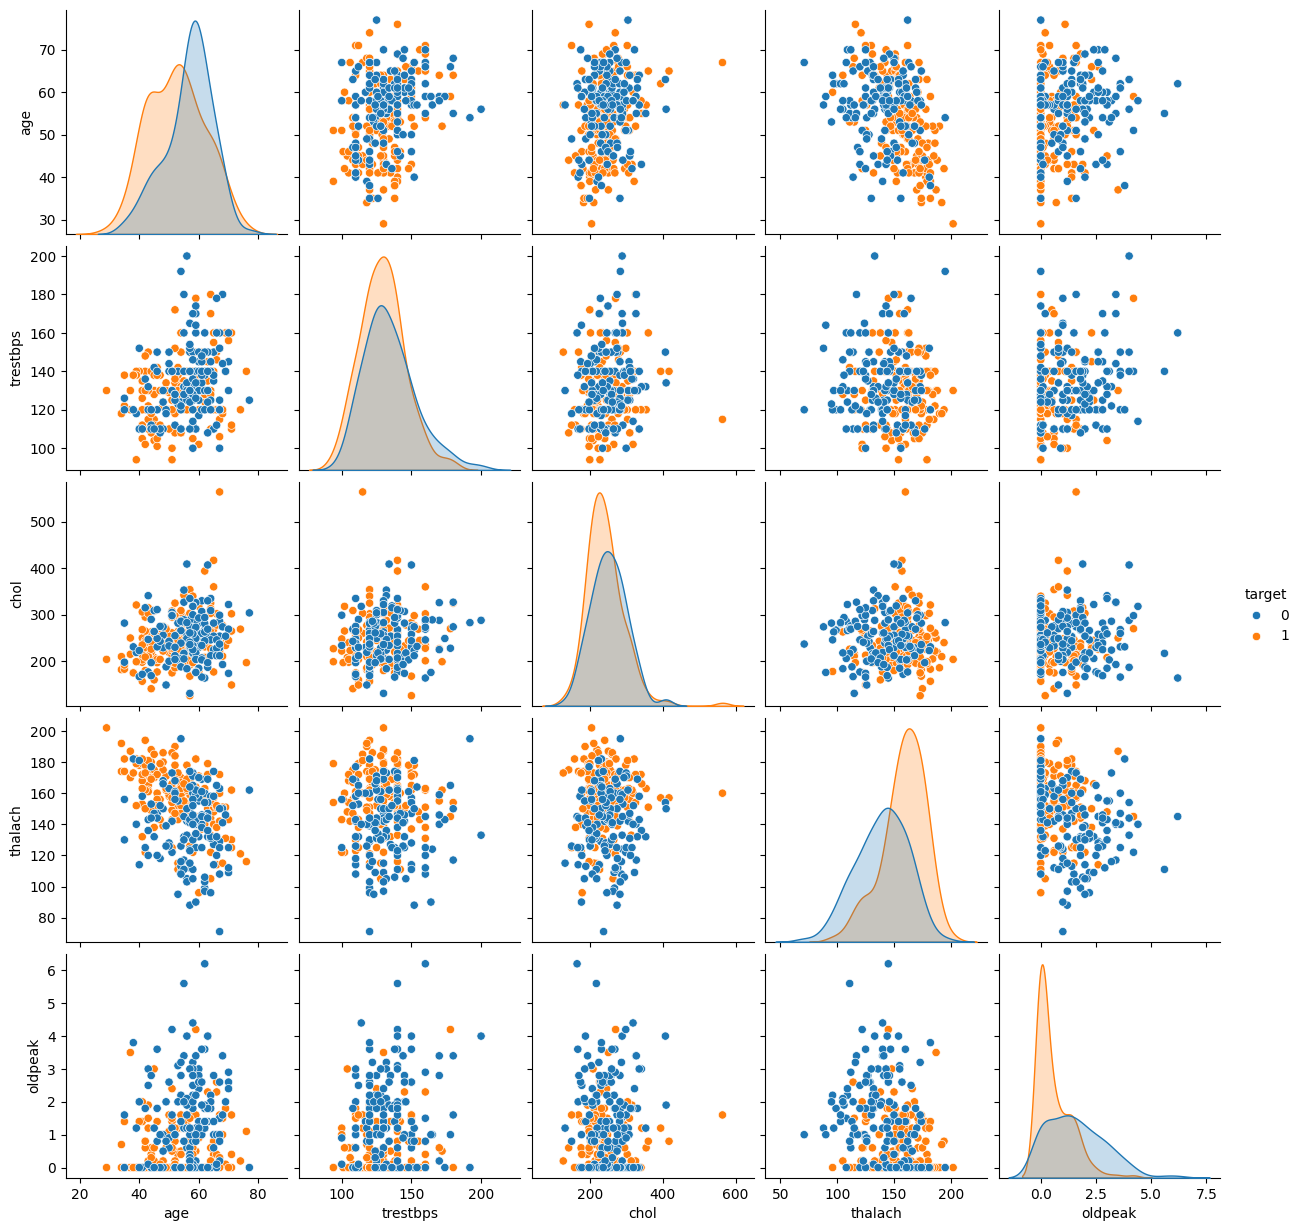

In [7]:
#Pairplot of Important Features

plt.figure(figsize=(12,8))
important_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.pairplot(df[important_features], hue='target')
plt.show()

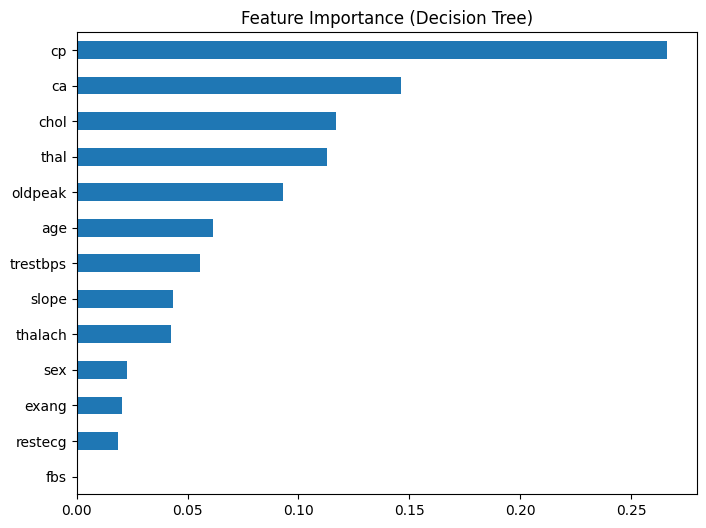

In [ ]:
#Feature Importance (Decision Tree)

dt_temp = DecisionTreeClassifier(random_state=42)
dt_temp.fit(df.drop('target', axis=1), df['target'])

importance = pd.Series(
    dt_temp.feature_importances_,
    index=df.drop('target', axis=1).columns
)

importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Decision Tree)")
plt.show()

### **Interpretation of Visualizations**
*   Age Distribution: Most patients fall in the middle-aged to older category, indicating that the risk of heart disease increases with age.
*   Gender vs Heart Disease: Males show a higher incidence of heart disease compared to females in the dataset.
*   Chest Pain Type vs Heart Disease: Certain chest pain types are strongly associated with the presence of heart disease, making it a critical predictive feature.**bold text**
*   Exercise Induced Angina: Patients experiencing exercise-induced angina have a significantly higher likelihood of heart disease.


#### **Overall Insight:**
These visualizations highlight that demographic factors, symptoms, and exercise-related indicators play a crucial role in predicting heart disease and justify their inclusion in the machine learning models.

In [ ]:
# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

log_model = LogisticRegression(random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

log_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Model Evaluation

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm.ravel()

print("Logistic Regression")
print("="*50)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("False Negatives:", fn)

Logistic Regression
Accuracy: 0.8524590163934426
Precision: 0.8709677419354839
Recall: 0.84375
F1: 0.8571428571428571
False Negatives: 5


In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

cm = confusion_matrix(y_test, y_pred_dt)
tn, fp, fn, tp = cm.ravel()

print("Decision Tree")
print("="*50)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1:", f1_score(y_test, y_pred_dt))
print("False Negatives:", fn)

Decision Tree
Accuracy: 0.7540983606557377
Precision: 0.84
Recall: 0.65625
F1: 0.7368421052631579
False Negatives: 11


In [ ]:
# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred_knn)
tn, fp, fn, tp = cm.ravel()

print("K-Nearest Neighbors")
print("="*50)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1:", f1_score(y_test, y_pred_knn))
print("False Negatives:", fn)

K-Nearest Neighbors
Accuracy: 0.9180327868852459
Precision: 0.9354838709677419
Recall: 0.90625
F1: 0.9206349206349206
False Negatives: 3


In [ ]:
print("Summary Table of all Models")
print("="*80)
summary_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "KNN"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_knn)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_knn)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_knn)
    ],

    "False Negatives": [
        confusion_matrix(y_test, y_pred_lr).ravel()[2],
        confusion_matrix(y_test, y_pred_dt).ravel()[2],
        confusion_matrix(y_test, y_pred_knn).ravel()[2]
    ]
})

summary_df

Summary Table of all Models


,Model,Accuracy,Precision,Recall,F1 Score,False Negatives
0,Logistic Regression,0.852459,0.870968,0.84375,0.857143,5
1,Decision Tree,0.754098,0.840000,0.65625,0.736842,11
2,KNN,0.918033,0.935484,0.90625,0.920635,3


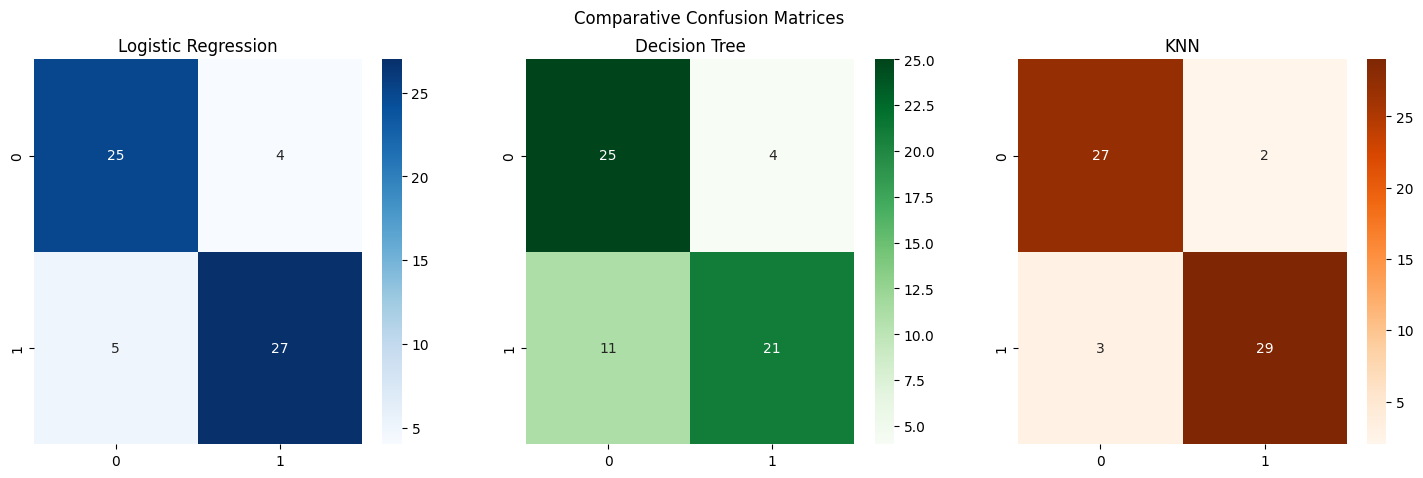

In [ ]:
# Comparative Confusion Matrix
from sklearn.metrics import confusion_matrix

y_pred_log = log_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

cm_log = confusion_matrix(y_test, y_pred_log)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression")

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Decision Tree")

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title("KNN")

plt.suptitle("Comparative Confusion Matrices")
plt.show()

### **Model Evaluation**

Model performance is evaluated using:
1. Accuracy, precision, recall, and F1-score
2. Confusion matrix analysis
3. ROC–AUC score for classification quality
4. Cross-validation to assess model stability

In medical screening tasks, recall is critically important to minimize false negatives, where a patient with heart disease is incorrectly classified as healthy, potentially delaying necessary treatment.


### **Risk-Based Prediction**
Instead of producing only binary predictions, the models output risk scores using predicted probabilities.

These scores represent the estimated likelihood of heart disease, offering a more informative and clinically meaningful assessment than hard class labels alone.

### **Model Interpretability**

To improve transparency, Logistic Regression coefficients are analyzed to understand feature influence.
This helps identify key clinical factors that contribute most strongly to heart disease risk and enhances trust in the model’s predictions.


### **Key Results & Takeaways**
*  Classical machine learning models can effectively predict heart disease risk using clinical data
*  Risk-based outputs provide more nuanced insight than binary classification
*  Logistic Regression achieves strong performance with high interpretability
*  Minimizing false negatives is essential in medical screening tasks

### **Future Improvements**

* Hyperparameter tuning to further improve model performance
* Bias and subgroup analysis to assess fairness across populations
* Cross-dataset validation for robustness
* Deployment as an educational or demonstration tool in the future